In [1]:
import duckdb
con = duckdb.connect()   # in-memory, nothing saved
con.sql("create view rides as select * from read_csv_auto('../data/dynamic_pricing.csv')")


def q(sql):
    """Run SQL and show the result as a table."""
    return con.sql(sql).df()

In [2]:
q("describe rides")

,column_name,column_type,null,key,default,extra
0,Number_of_Riders,BIGINT,YES,None,None,None
1,Number_of_Drivers,BIGINT,YES,None,None,None
2,Location_Category,VARCHAR,YES,None,None,None
3,Customer_Loyalty_Status,VARCHAR,YES,None,None,None
4,Number_of_Past_Rides,BIGINT,YES,None,None,None
5,Average_Ratings,DOUBLE,YES,None,None,None
6,Time_of_Booking,VARCHAR,YES,None,None,None
7,Vehicle_Type,VARCHAR,YES,None,None,None
8,Expected_Ride_Duration,BIGINT,YES,None,None,None
9,Historical_Cost_of_Ride,DOUBLE,YES,None,None,None


In [3]:
con.sql("""
create or replace view stg_rides as

with source as (

    select * from read_csv_auto('../data/dynamic_pricing.csv')

),

renamed as (

    select
        -- ride context (categories)
        cast(Location_Category       as varchar) as location_category,
        cast(Time_of_Booking         as varchar) as booking_time_of_day,
        cast(Vehicle_Type            as varchar) as vehicle_type,
        cast(Customer_Loyalty_Status as varchar) as customer_loyalty_status,

        -- customer
        cast(Number_of_Past_Rides    as integer) as customer_past_ride_count,
        cast(Average_Ratings         as double)  as customer_avg_rating,

        -- market at booking time
        cast(Number_of_Riders        as integer) as market_rider_count,
        cast(Number_of_Drivers       as integer) as market_driver_count,

        -- trip
        cast(Expected_Ride_Duration  as integer) as expected_ride_duration_minutes,

        -- target
        cast(Historical_Cost_of_Ride as double)  as historical_ride_cost

    from source

)

select * from renamed
""")

q("select * from stg_rides limit 10")

,location_category,booking_time_of_day,vehicle_type,customer_loyalty_status,customer_past_ride_count,customer_avg_rating,market_rider_count,market_driver_count,expected_ride_duration_minutes,historical_ride_cost
0,Urban,Night,Premium,Silver,13,4.47,90,45,90,284.257273
1,Suburban,Evening,Economy,Silver,72,4.06,58,39,43,173.874753
2,Rural,Afternoon,Premium,Silver,0,3.99,42,31,76,329.795469
3,Rural,Afternoon,Premium,Regular,67,4.31,89,28,134,470.201232
4,Rural,Afternoon,Economy,Regular,74,3.77,78,22,149,579.681422
5,Urban,Night,Economy,Silver,83,3.51,59,35,128,339.955361
6,Suburban,Afternoon,Premium,Regular,44,4.41,93,43,16,104.061541
7,Rural,Afternoon,Premium,Gold,83,3.59,62,39,47,235.811864
8,Rural,Evening,Economy,Silver,71,3.74,79,14,128,501.412517
9,Rural,Night,Premium,Silver,21,3.85,42,6,128,398.993365


In [4]:
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
import pandas as pd
import matplotlib.pyplot as plt

BLUE, ORANGE = "#2a78d6", "#eb6834"
plt.rcParams.update({
    "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#b5b4ae", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "grid.color": "#e8e7e3", "grid.linewidth": 0.8,
    "axes.axisbelow": True, "axes.titlesize": 11, "axes.titleweight": "bold",
})

rides = q("""
    select
        *,
        historical_ride_cost / expected_ride_duration_minutes as cost_per_minute,
        market_rider_count / market_driver_count              as riders_per_driver
    from stg_rides
""")
rides.head()

,location_category,booking_time_of_day,vehicle_type,customer_loyalty_status,customer_past_ride_count,customer_avg_rating,market_rider_count,market_driver_count,expected_ride_duration_minutes,historical_ride_cost,cost_per_minute,riders_per_driver
0,Urban,Night,Premium,Silver,13,4.47,90,45,90,284.257273,3.158414,2.000000
1,Suburban,Evening,Economy,Silver,72,4.06,58,39,43,173.874753,4.043599,1.487179
2,Rural,Afternoon,Premium,Silver,0,3.99,42,31,76,329.795469,4.339414,1.354839
3,Rural,Afternoon,Premium,Regular,67,4.31,89,28,134,470.201232,3.508964,3.178571
4,Rural,Afternoon,Economy,Regular,74,3.77,78,22,149,579.681422,3.890479,3.545455


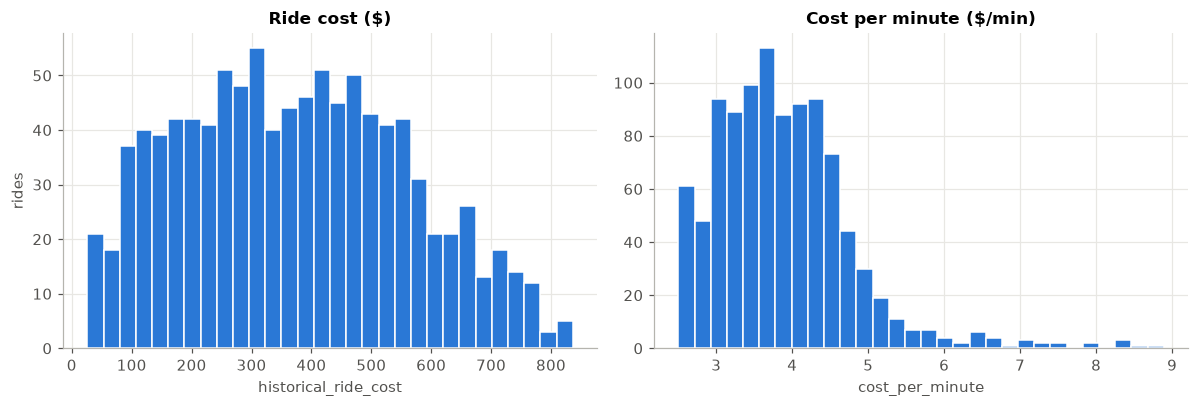

,historical_ride_cost,cost_per_minute
count,1000.00,1000.00
mean,372.50,3.89
std,187.16,0.91
min,25.99,2.50
25%,221.37,3.24
50%,362.02,3.77
75%,510.50,4.35
max,836.12,8.89


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

axes[0].hist(rides["historical_ride_cost"], bins=30, color=BLUE, edgecolor="white", linewidth=1)
axes[0].set_title("Ride cost ($)")
axes[0].set_xlabel("historical_ride_cost")
axes[0].set_ylabel("rides")

axes[1].hist(rides["cost_per_minute"], bins=30, color=BLUE, edgecolor="white", linewidth=1)
axes[1].set_title("Cost per minute ($/min)")
axes[1].set_xlabel("cost_per_minute")

plt.tight_layout()
plt.show()

rides[["historical_ride_cost", "cost_per_minute"]].describe().round(2)

### 💡 Insight: Cost distribution

**What we see**
- Fares range from ~$25 to ~$830, spread fairly evenly between $100 and $600, with no single "typical" fare.
- Most rides are charged $2.70–$4.50 per minute, with nothing below ~$2.50 and a small tail up to ~$9.

**What it likely means**
- The per-minute rate is fairly consistent, so most of the variation in fares comes from something other than the rate.
- The hard edge at ~$2.50/min suggests a minimum rate in today's pricing.
- The high-rate tail is unexplained by this chart alone.

**What we'll do next**
- Check what drives fare size (Cell 3: duration vs cost).
- Investigate which rides sit in the high cost-per-minute tail.

The target has a normal, well-behaved range. The per-minute rate has a floor and a small high tail worth investigating.

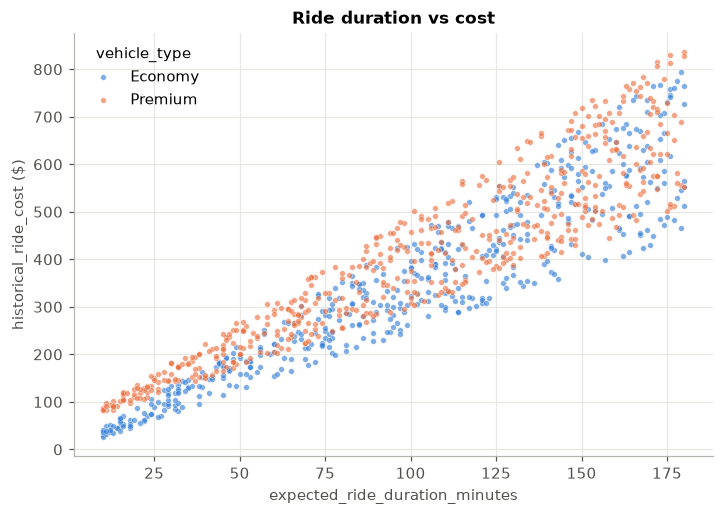

,vehicle_type,corr_duration_cost,rides
0,Premium,0.933,522
1,Economy,0.936,478
2,All,0.928,1000


In [7]:
fig, ax = plt.subplots(figsize=(7.5, 5))

for vehicle, color in [("Economy", BLUE), ("Premium", ORANGE)]:
    subset = rides[rides["vehicle_type"] == vehicle]
    ax.scatter(subset["expected_ride_duration_minutes"], subset["historical_ride_cost"],
               s=14, alpha=0.6, color=color, edgecolor="white", linewidth=0.4, label=vehicle)

ax.set_title("Ride duration vs cost")
ax.set_xlabel("expected_ride_duration_minutes")
ax.set_ylabel("historical_ride_cost ($)")
ax.legend(title="vehicle_type", frameon=False)
plt.show()

q("""
    select vehicle_type,
           round(corr(expected_ride_duration_minutes, historical_ride_cost), 3) as corr_duration_cost,
           count(*) as rides
    from stg_rides
    group by all
    union all
    select 'All', round(corr(expected_ride_duration_minutes, historical_ride_cost), 3), count(*)
    from stg_rides
""")

What we see: Cost rises steadily with duration, and Premium sits above Economy. The spread widens for longer rides.
What it likely means: Duration is the main driver of fare, which matches "today's price depends on duration." The widening spread means something else adds variation on longer rides.
What we'll do next: Duration-only will be a strong baseline. Check whether the other columns explain the extra spread.

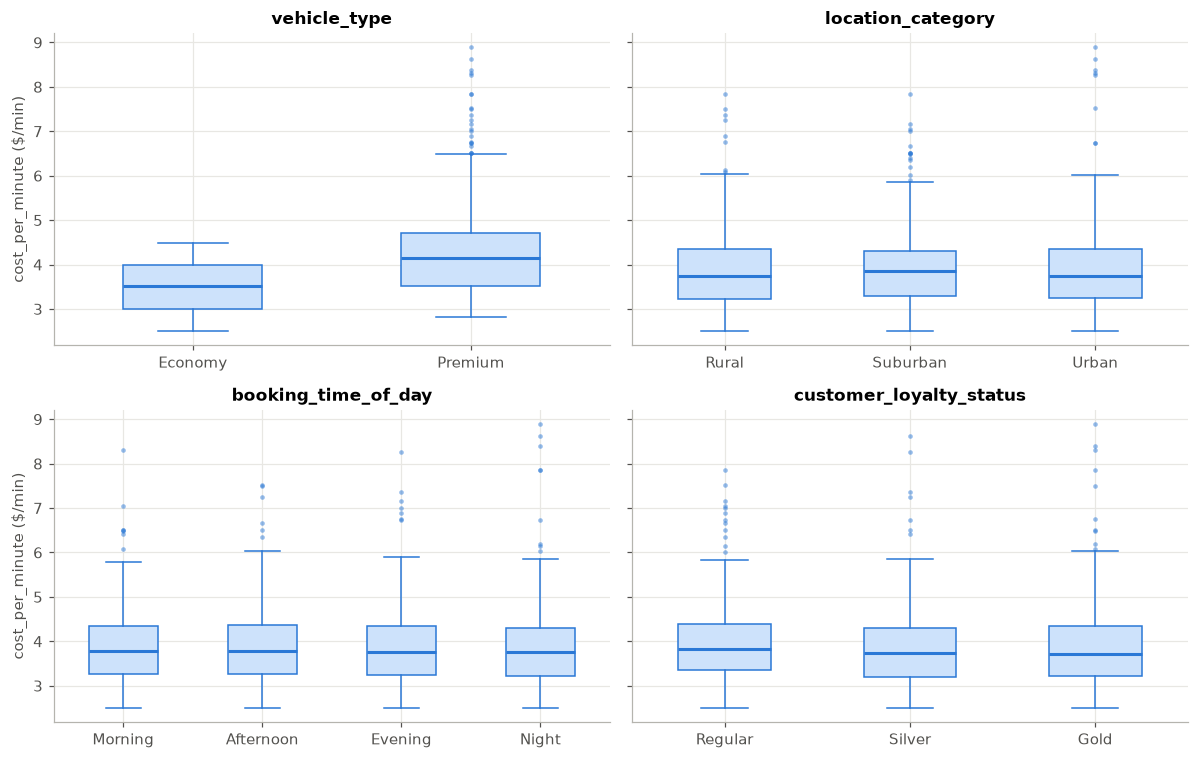

,count,mean,median
vehicle_type,,,
Economy,478,3.49,3.51
Premium,522,4.25,4.16


,count,mean,median
location_category,,,
Rural,332,3.87,3.75
Suburban,322,3.91,3.86
Urban,346,3.89,3.74


,count,mean,median
booking_time_of_day,,,
Morning,246,3.88,3.79
Afternoon,247,3.87,3.78
Evening,231,3.92,3.76
Night,276,3.89,3.76


,count,mean,median
customer_loyalty_status,,,
Regular,320,3.95,3.83
Silver,367,3.83,3.75
Gold,313,3.89,3.72


In [8]:
category_orders = {
    "vehicle_type":            ["Economy", "Premium"],
    "location_category":       ["Rural", "Suburban", "Urban"],
    "booking_time_of_day":     ["Morning", "Afternoon", "Evening", "Night"],
    "customer_loyalty_status": ["Regular", "Silver", "Gold"],
}

fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharey=True)

for ax, (col, order) in zip(axes.flat, category_orders.items()):
    groups = [rides.loc[rides[col] == value, "cost_per_minute"] for value in order]
    ax.boxplot(groups, tick_labels=order, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor="#cde2fb", edgecolor=BLUE),
               medianprops=dict(color=BLUE, linewidth=2),
               whiskerprops=dict(color=BLUE), capprops=dict(color=BLUE),
               flierprops=dict(marker="o", markersize=3, markerfacecolor=BLUE, markeredgecolor="none", alpha=0.5))
    ax.set_title(col)

axes[0, 0].set_ylabel("cost_per_minute ($/min)")
axes[1, 0].set_ylabel("cost_per_minute ($/min)")
plt.tight_layout()
plt.show()

for col, order in category_orders.items():
    display(
        rides.groupby(col)["cost_per_minute"]
             .agg(["count", "mean", "median"]).round(2)
             .reindex(order)
    )

What we see: Premium rides are charged more per minute than Economy, and all high-rate outliers are Premium. Location, time of day and loyalty show no difference.
What it likely means: Vehicle type is part of today's pricing. Location, time and loyalty are not, so today's price doesn't react to when or where a ride happens.
What we'll do next: Keep vehicle type as a model feature. Expect location, time and loyalty to add little.

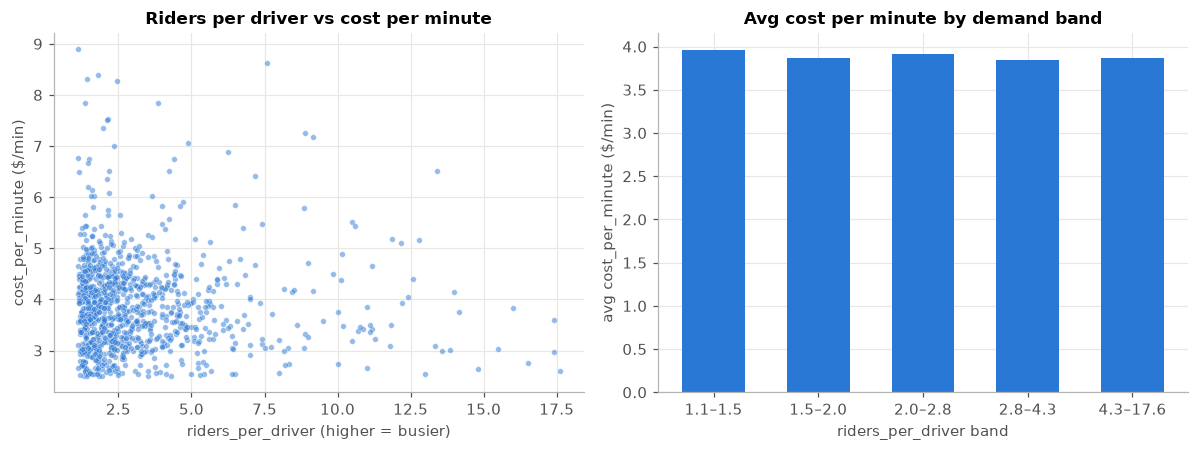

,market_rider_count,market_driver_count,riders_per_driver,historical_ride_cost,cost_per_minute
market_rider_count,1.000,0.627,0.071,0.006,0.030
market_driver_count,0.627,1.000,-0.564,0.017,0.057
riders_per_driver,0.071,-0.564,1.000,-0.094,-0.033
historical_ride_cost,0.006,0.017,-0.094,1.000,-0.047
cost_per_minute,0.030,0.057,-0.033,-0.047,1.000


In [9]:
rides["riders_per_driver_band"] = pd.qcut(rides["riders_per_driver"], q=5)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].scatter(rides["riders_per_driver"], rides["cost_per_minute"],
                s=14, alpha=0.5, color=BLUE, edgecolor="white", linewidth=0.4)
axes[0].set_title("Riders per driver vs cost per minute")
axes[0].set_xlabel("riders_per_driver (higher = busier)")
axes[0].set_ylabel("cost_per_minute ($/min)")

band_means = rides.groupby("riders_per_driver_band", observed=True)["cost_per_minute"].mean()
band_labels = [f"{b.left:.1f}–{b.right:.1f}" for b in band_means.index]
axes[1].bar(band_labels, band_means.values, color=BLUE, width=0.6)
axes[1].set_title("Avg cost per minute by demand band")
axes[1].set_xlabel("riders_per_driver band")
axes[1].set_ylabel("avg cost_per_minute ($/min)")

plt.tight_layout()
plt.show()

rides[["market_rider_count", "market_driver_count", "riders_per_driver",
       "historical_ride_cost", "cost_per_minute"]].corr().round(3)

What we see: Cost per minute is flat across all demand levels, around $3.90 whether a ride is 1 or 17 riders per driver.
What it likely means: Today's pricing does not react to demand or supply. This confirms the brief: price ignores market conditions.
What we'll do next: Riders per driver won't improve a model of historical cost, but it's the key input for the dynamic pricing rule in Stage 5.

In [10]:
numeric_cols = ["customer_past_ride_count", "customer_avg_rating",
                "market_rider_count", "market_driver_count", "riders_per_driver",
                "expected_ride_duration_minutes", "historical_ride_cost", "cost_per_minute"]

rides[numeric_cols].corr().round(2)

,customer_past_ride_count,customer_avg_rating,market_rider_count,market_driver_count,riders_per_driver,expected_ride_duration_minutes,historical_ride_cost,cost_per_minute
customer_past_ride_count,1.00,-0.06,0.03,0.04,-0.02,0.03,0.04,-0.00
customer_avg_rating,-0.06,1.00,0.01,0.04,-0.02,-0.02,-0.00,0.03
market_rider_count,0.03,0.01,1.00,0.63,0.07,-0.02,0.01,0.03
market_driver_count,0.04,0.04,0.63,1.00,-0.56,-0.02,0.02,0.06
riders_per_driver,-0.02,-0.02,0.07,-0.56,1.00,-0.06,-0.09,-0.03
expected_ride_duration_minutes,0.03,-0.02,-0.02,-0.02,-0.06,1.00,0.93,-0.33
historical_ride_cost,0.04,-0.00,0.01,0.02,-0.09,0.93,1.00,-0.05
cost_per_minute,-0.00,0.03,0.03,0.06,-0.03,-0.33,-0.05,1.00


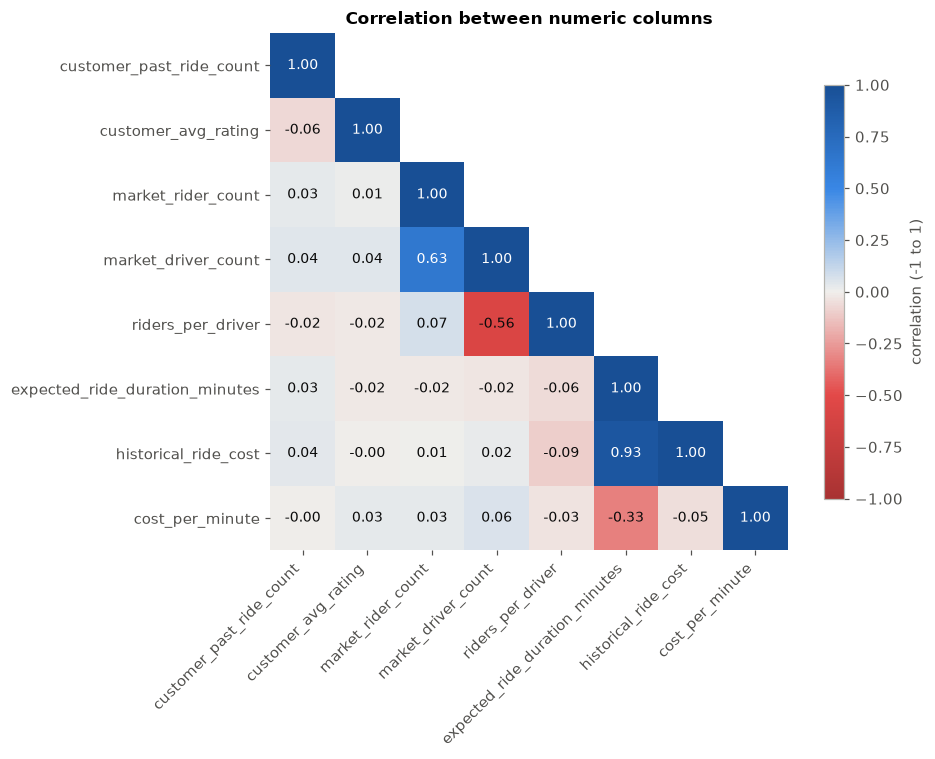

In [11]:
import numpy as np
from matplotlib.colors import LinearSegmentedColormap

corr = rides[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)        # hide the mirror-image upper half
diverging = LinearSegmentedColormap.from_list(
    "diverging", ["#a83232", "#e34948", "#f0efec", "#3987e5", "#184f95"])

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(np.ma.masked_array(corr, mask), cmap=diverging, vmin=-1, vmax=1)

for i in range(len(corr)):
    for j in range(i + 1):
        value = corr.iloc[i, j]
        ax.text(j, i, f"{value:.2f}", ha="center", va="center", fontsize=9,
                color="white" if abs(value) > 0.6 else "#0b0b0b")

ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha="right")
ax.set_yticks(range(len(corr)), corr.columns)
ax.grid(False)
ax.spines[:].set_visible(False)
ax.set_title("Correlation between numeric columns")
fig.colorbar(im, ax=ax, shrink=0.8, label="correlation (-1 to 1)")
plt.tight_layout()
plt.show()

What we see: Cost is strongly linked to duration (0.93). Every other numeric column shows almost no link to cost.
What it likely means: Among the numeric columns, duration alone explains most of today's price, and market conditions play no part.
What we'll do next: Expect the duration-only baseline to be hard to beat. Any gain will need to come from categories like vehicle type.